#Clustering

Understanding and Implementing K-Means and DBSCAN Algorithms

Objective:

The objective of this assignment is to introduce to various clustering algorithms, including K-Means, hierarchical, and DBSCAN, and provide hands-on experience in applying these techniques to a real-world dataset.


Data Preprocessing:

1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.

2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.

3.	Use multiple visualizations to understand the hidden patterns in the dataset


In [46]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, DBSCAN

# Evaluation Metrics
from sklearn.metrics import silhouette_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [47]:
file_path = r"EastWestAirlines.xlsx"

# Load  dataset sheet
df = pd.read_excel(file_path, sheet_name='data')

# Display dataset
print(df.head())

# Dataset info
print(df.info())

   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
4    5    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
4           26               2077                4               6935       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 en

In [48]:
#Shape of Dataset
print("Shape of Dataset:", df.shape)
#Dataset Information
print(df.info())
#Statistical Summary
print(df.describe())
#Check Missing Values
print(df.isnull().sum())

Shape of Dataset: (3999, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB
None
               ID#       Balance    Qual_miles    cc1_miles    cc2_miles  \
count  3999.000000  3.999000e+03   3999.000000  3999.000000  3999.000000   
mean   2014.819455  7.

In [49]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Handle Outliers Using IQR Method
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)

IQR = Q3 - Q1

# Remove outliers
df = df[~((numeric_df < (Q1 - 1.5 * IQR)) |
          (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

print(df.shape)

(2875, 12)


In [50]:
# Select  numeric columns

numeric_df = df.select_dtypes(include=np.number)

print(numeric_df.head())

   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
5    6    16420           0          1          1          1            0   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
5            0                  0                0               6942       0  


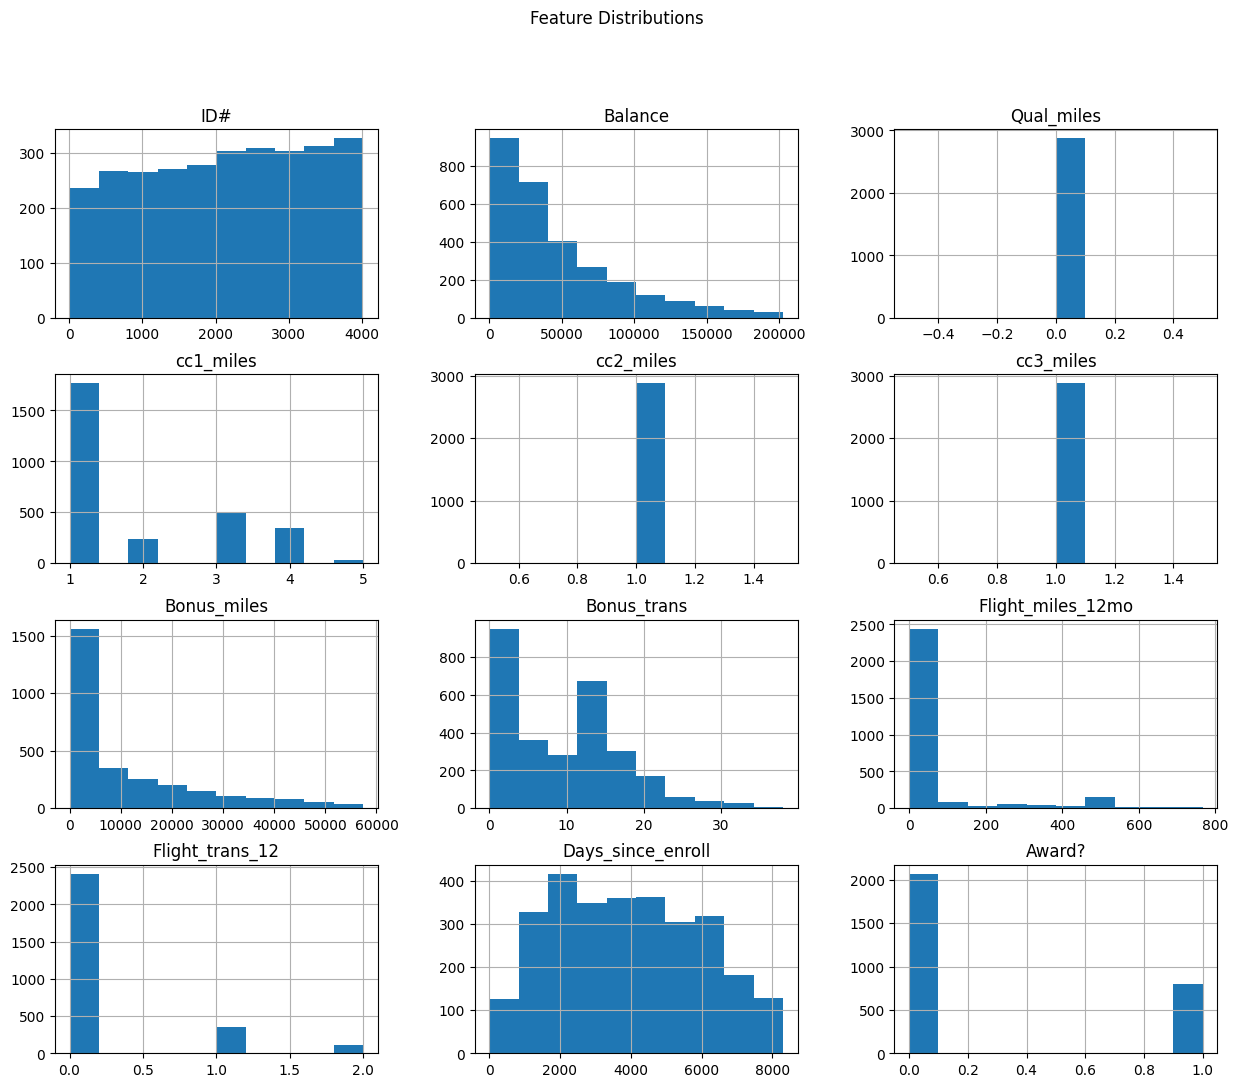

In [51]:
#Histograms
numeric_df.hist(figsize=(15,12))

plt.suptitle("Feature Distributions")

plt.show()

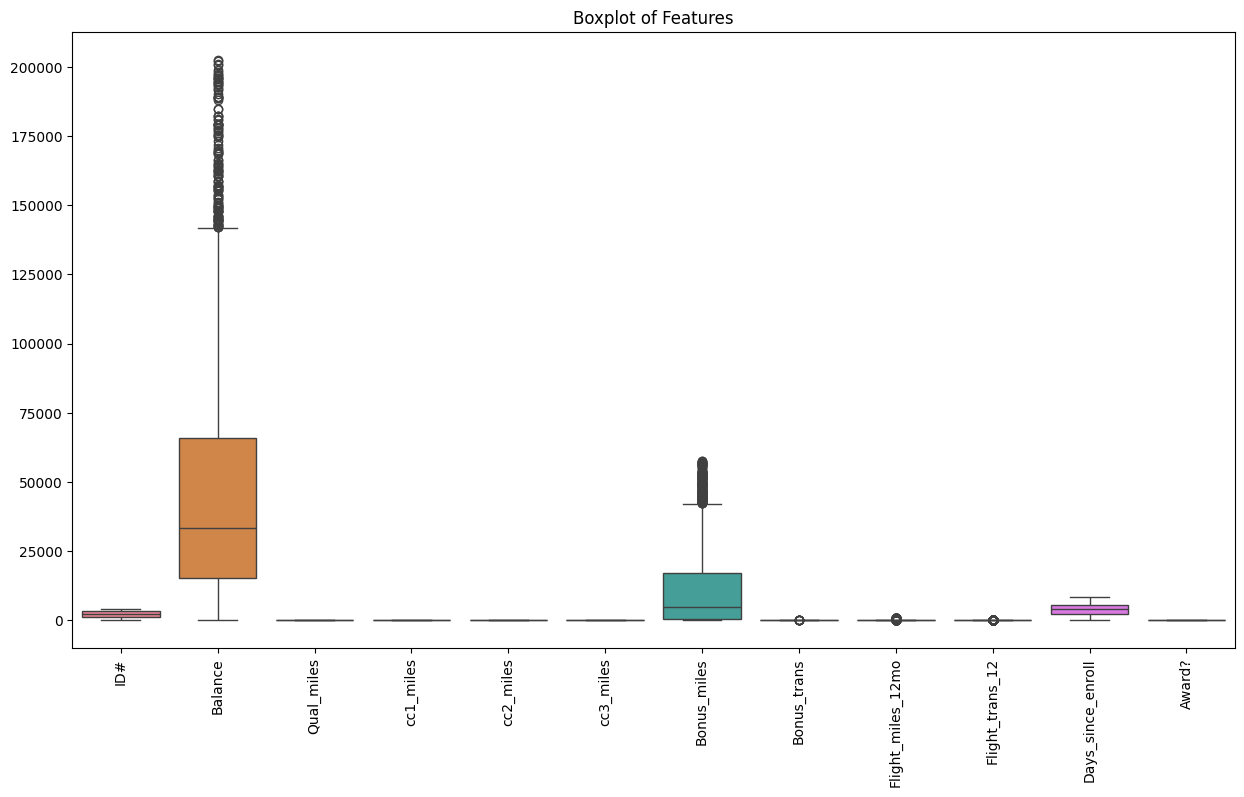

In [52]:
#Boxplots
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot of Features")
plt.show()

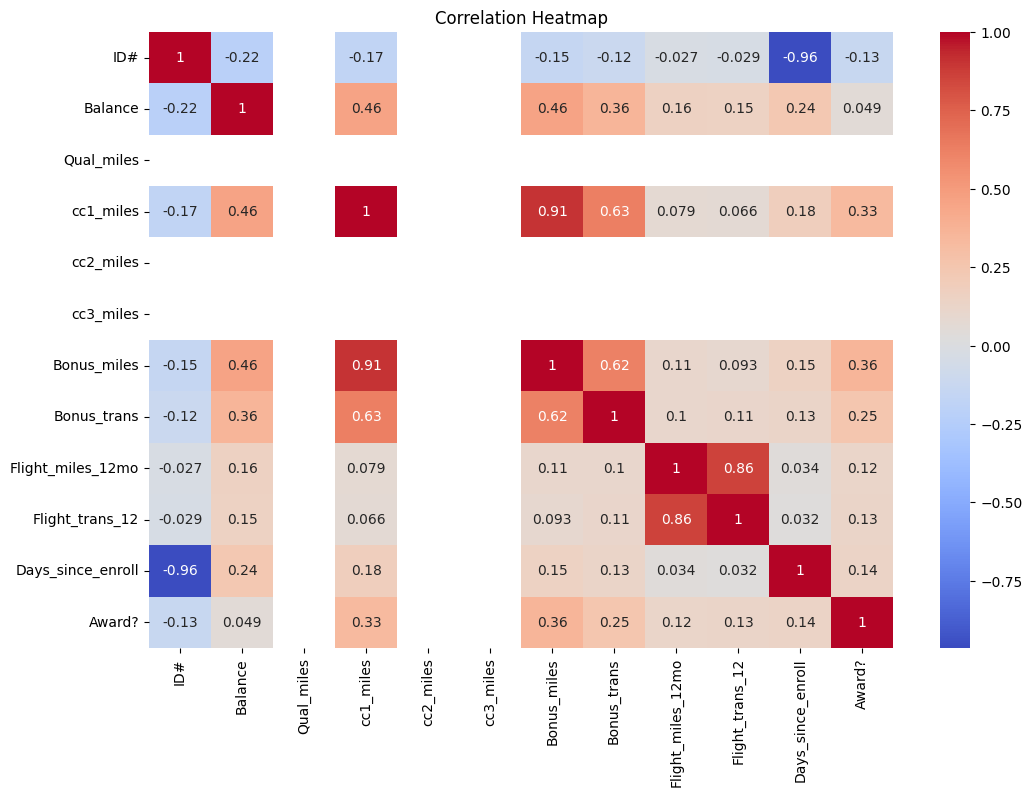

In [45]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

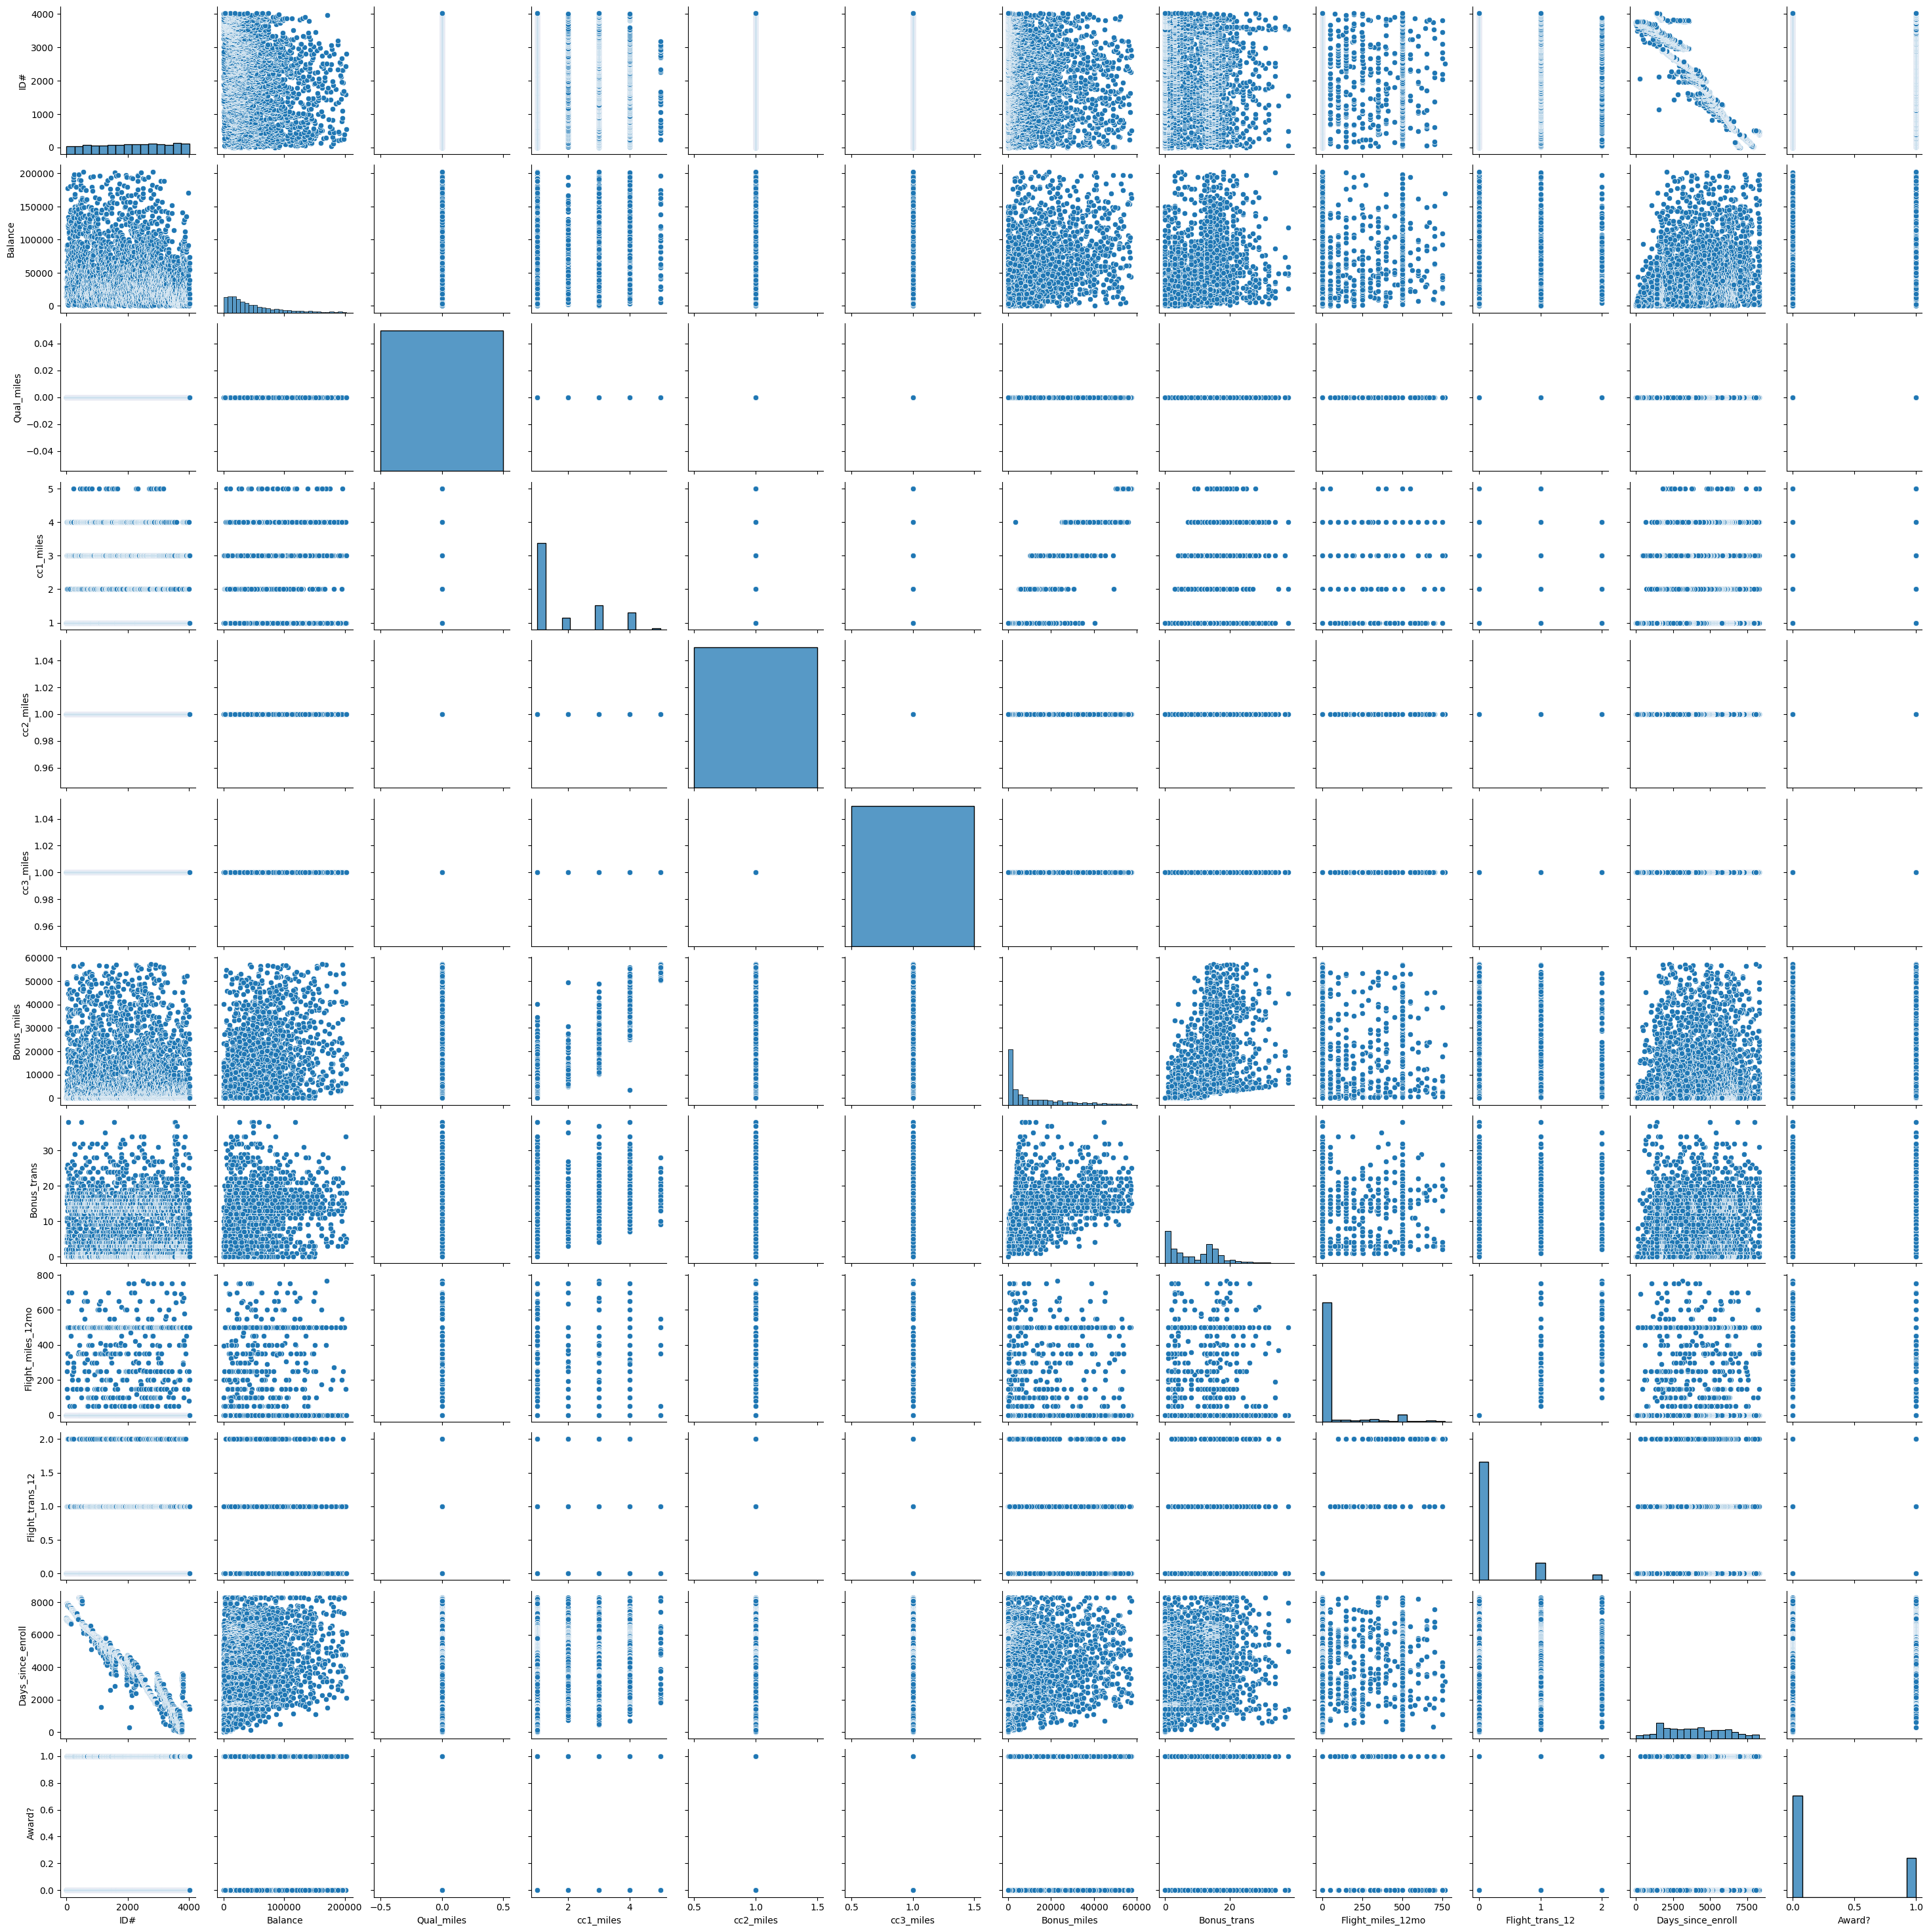

In [53]:
#Pairplot
sns.pairplot(df)
plt.show()

Implementing Clustering Algorithms:

•	Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.

•	Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.

•	Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.


Visualization:

Visualize the clustering results using scatter plots or other suitable visualization techniques.

Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.


In [54]:
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Scale numeric data
scaled_data = scaler.fit_transform(numeric_df)

# Display scaled data
print(scaled_data)


[[-1.83464329 -0.43885929  0.         ... -0.40970772  1.50369284
  -0.62307163]
 [-1.83377495 -0.64773487  0.         ... -0.40970772  1.48803468
  -0.62307163]
 [-1.83290661 -0.1287733   0.         ... -0.40970772  1.52032964
  -0.62307163]
 ...
 [ 1.65435035  0.62802805  0.         ... -0.40970772 -1.23550729
   1.60495191]
 [ 1.65521869  0.18915227  0.         ...  1.65318143 -1.23599661
  -0.62307163]
 [ 1.65608703 -1.02863529  0.         ... -0.40970772 -1.23746456
  -0.62307163]]


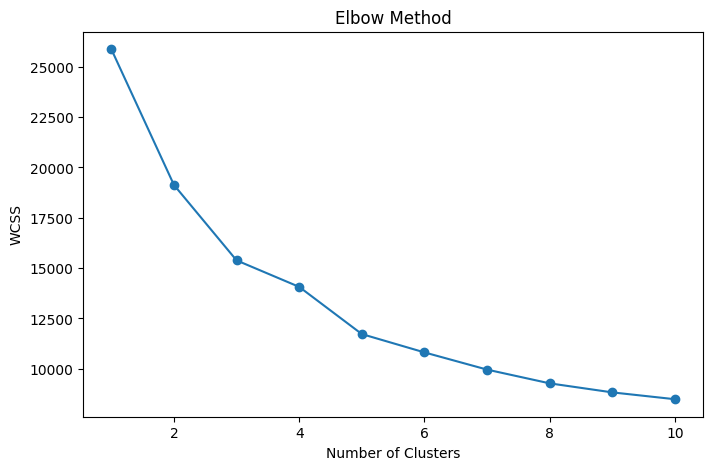

In [55]:
#Finding Optimal K using Elbow Method
wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [56]:
#Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans_labels = kmeans.fit_predict(scaled_data)

print(kmeans_labels)


[1 1 1 ... 2 0 1]


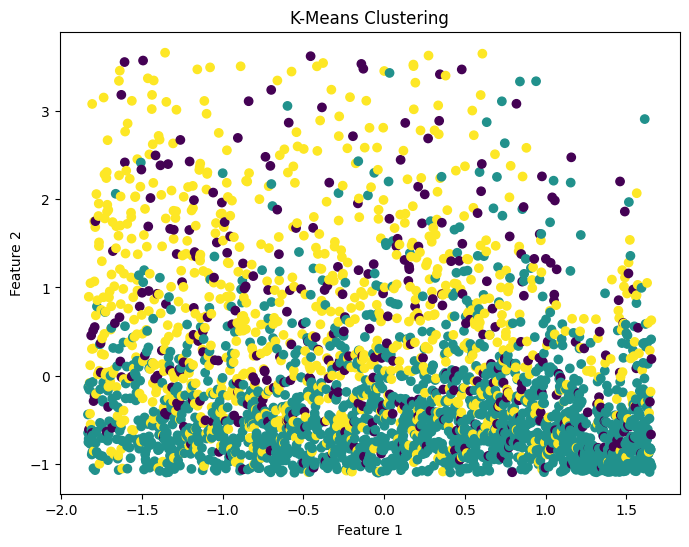

In [57]:
# K-Means Cluster Visualization

plt.figure(figsize=(8,6))

plt.scatter(scaled_data[:,0], scaled_data[:,1], c=kmeans_labels, cmap='viridis')

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [58]:
#K-Means Evaluation
#Silhouette Score

kmeans_silhouette = silhouette_score(scaled_data, kmeans_labels)

print("K-Means Silhouette Score:", kmeans_silhouette)

K-Means Silhouette Score: 0.30830264215957265


In [59]:
#Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(scaled_data)

print(dbscan_labels)


[0 0 0 ... 2 3 0]


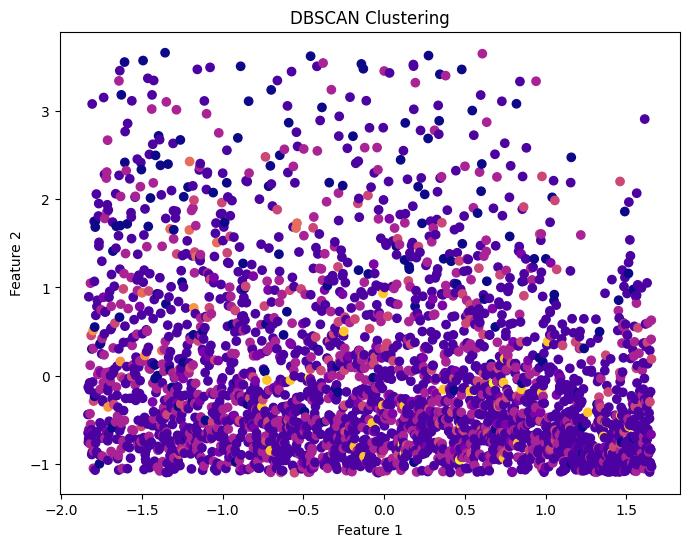

In [60]:
#DBSCAN Visualization
plt.figure(figsize=(8,6))

plt.scatter(scaled_data[:,0], scaled_data[:,1], c=dbscan_labels, cmap='plasma')

plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [61]:
#Silhouette Score
# Remove noise points (-1)
mask = dbscan_labels != -1

dbscan_silhouette = silhouette_score( scaled_data[mask], dbscan_labels[mask])

print("DBSCAN Silhouette Score:", dbscan_silhouette)

DBSCAN Silhouette Score: 0.22510017066325644


Cluster Analysis and Interpretation:

•	Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.


In [62]:
"""K-Means Insights
K-Means divided the dataset into fixed clusters.
It performed well when clusters were spherical and evenly distributed.
The Elbow Method helped determine the optimal number of clusters.
"""

'K-Means Insights\nK-Means divided the dataset into fixed clusters.\nIt performed well when clusters were spherical and evenly distributed.\nThe Elbow Method helped determine the optimal number of clusters.\n'

In [63]:
"""DBSCAN Insights
DBSCAN identified dense regions and detected noise points.
It handled irregular cluster shapes effectively.
No need to specify the number of clusters beforehand."""

'DBSCAN Insights\nDBSCAN identified dense regions and detected noise points.\nIt handled irregular cluster shapes effectively.\nNo need to specify the number of clusters beforehand.'

In [64]:
"""

K-Means	---> DBSCAN
Requires K value ---> No need for K
Sensitive to outliers --->	Handles outliers well
Works well for spherical clusters --->	Works well for irregular clusters
Faster computation --->	Slightly slower
"""

'\n\nK-Means\t---> DBSCAN\nRequires K value ---> No need for K\nSensitive to outliers --->\tHandles outliers well\nWorks well for spherical clusters --->\tWorks well for irregular clusters\nFaster computation --->\tSlightly slower \n'

In [65]:
"""
K-Means When:
Number of clusters is known
Data is evenly distributed
Fast computation is required
Clusters are spherical in shape

DBSCAN When:
Dataset contains noise or outliers
Cluster shapes are irregular
Number of clusters is unknown
Density-based clustering is needed

"""

'\nK-Means When:\nNumber of clusters is known\nData is evenly distributed\nFast computation is required\nClusters are spherical in shape\n\nDBSCAN When:\nDataset contains noise or outliers\nCluster shapes are irregular\nNumber of clusters is unknown\nDensity-based clustering is needed\n\n'

In [66]:
"""
Both K-Means and DBSCAN are powerful clustering algorithms with different strengths.
K-Means is efficient and simple for well-structured datasets, while DBSCAN is more robust for datasets containing noise and irregular cluster structures.
Choosing the right algorithm depends on the nature of the dataset and the business problem being solved.
"""

'\nBoth K-Means and DBSCAN are powerful clustering algorithms with different strengths.\nK-Means is efficient and simple for well-structured datasets, while DBSCAN is more robust for datasets containing noise and irregular cluster structures.\nChoosing the right algorithm depends on the nature of the dataset and the business problem being solved.\n'